In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
url_data = "https://api.scb.se/OV0104/v1/doris/en/ssd/START/BO/BO0501/BO0501A/FastpiPSRegAr"

params = {
    "query": [
        {
            "code": "Region",
            "selection": {
                "filter": "item",
                "values": ["0020"]
            }
        },
        {
            "code": "ContentsCode",
            "selection": {
                "filter": "item",
                "values": ["BO0501N9"]
            }
        },
        {
            "code": "Tid",
            "selection": {
                "filter": "item",
                "values": ["2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]
            }
        }
    ],
    "response": {
        "format": "json"
    }
}

response_data = requests.post(url_data, json=params)
print("Status:", response_data.status_code)
print(response_data.json())

Status: 200
{'columns': [{'code': 'Region', 'text': 'region', 'type': 'd'}, {'code': 'Tid', 'text': 'year', 'type': 't'}, {'code': 'BO0501N9', 'text': 'Index', 'type': 'c'}], 'comments': [], 'data': [{'key': ['0020', '2015'], 'values': ['875']}, {'key': ['0020', '2016'], 'values': ['922']}, {'key': ['0020', '2017'], 'values': ['1022']}, {'key': ['0020', '2018'], 'values': ['1014']}, {'key': ['0020', '2019'], 'values': ['1045']}, {'key': ['0020', '2020'], 'values': ['1098']}, {'key': ['0020', '2021'], 'values': ['1271']}, {'key': ['0020', '2022'], 'values': ['1311']}, {'key': ['0020', '2023'], 'values': ['1172']}, {'key': ['0020', '2024'], 'values': ['1165']}], 'metadata': [{'infofile': 'BO0501', 'updated': '2026-03-09T13:05:00Z', 'label': 'Real estate price index for one- or two-dwelling buildings for permanent living (1981=100), index by region, year and observations', 'source': 'Statistics Sweden'}]}


In [12]:
data = response_data.json()

years = []
index_values = []

for item in data['data']:
    years.append(int(item['key'][1]))
    index_values.append(int(item['values'][0]))

df = pd.DataFrame({
    'year': years,
    'price_index': index_values
})

print(df)

   year  price_index
0  2015          875
1  2016          922
2  2017         1022
3  2018         1014
4  2019         1045
5  2020         1098
6  2021         1271
7  2022         1311
8  2023         1172
9  2024         1165


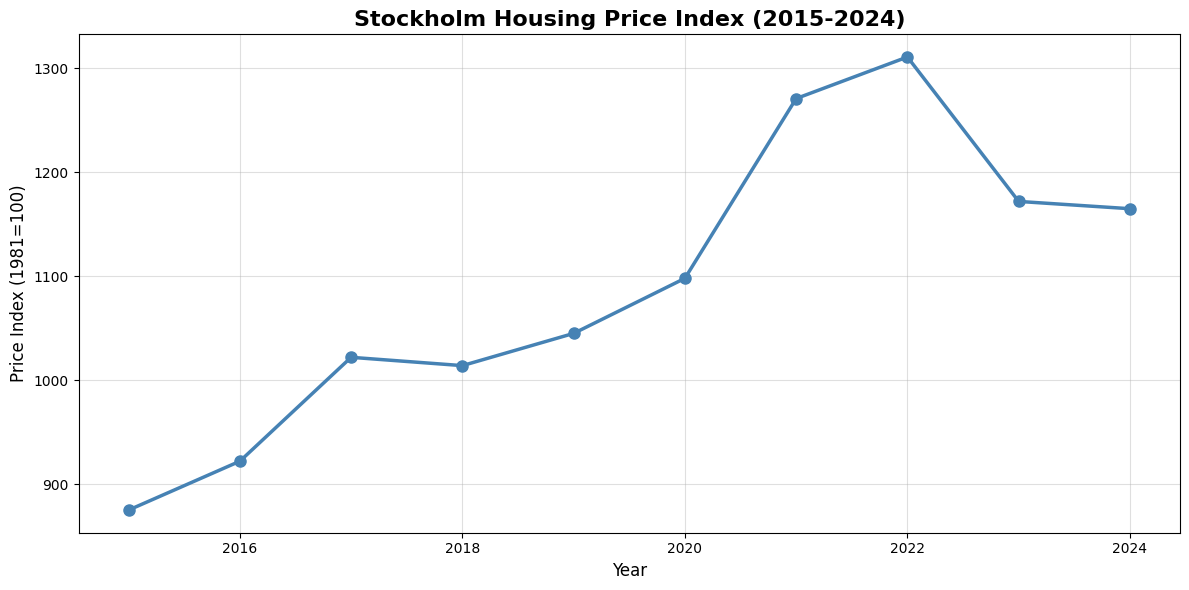

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(df['year'], df['price_index'], 
         marker='o', 
         linewidth=2.5, 
         color='steelblue',
         markersize=8)

plt.title('Stockholm Housing Price Index (2015-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price Index (1981=100)', fontsize=12)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('stockholm_price_index.png', dpi=150)
plt.show()

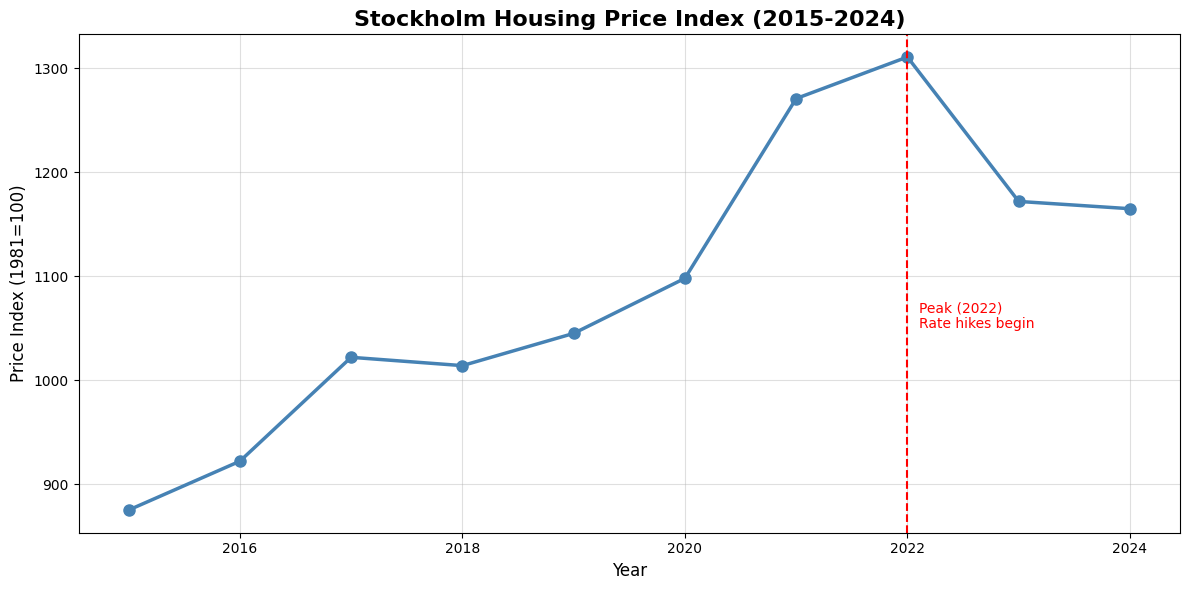

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(df['year'], df['price_index'], 
         marker='o', 
         linewidth=2.5, 
         color='steelblue',
         markersize=8)

plt.axvline(x=2022, color='red', linestyle='--', linewidth=1.5)
plt.text(2022.1, 1050, 'Peak (2022)\nRate hikes begin', 
         color='red', fontsize=10)

plt.title('Stockholm Housing Price Index (2015-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price Index (1981=100)', fontsize=12)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('stockholm_price_index.png', dpi=150)
plt.show()